In [34]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import petab
import seaborn as sns

_project_root = str(
    next(
        (
            _p
            for _p in (Path.cwd(), *Path.cwd().parents)
            if (_p / "common.py").is_file()
        ),
        Path.cwd().parent,
    )
)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer

from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import contextualize_measurements
from util import load_petab_base_files

DATA = "dream_cytof"
MODEL = "EGFR_MAPK__logobs"

# updated load_petab_base_files takes in a Conf object as argument
conf = Conf(model=MODEL, data=DATA)
files = load_petab_base_files(conf)
# Get the list of all cell-lines APART from test cell-lines
all_samples = sorted(get_samples(conf.data)[:-5])
print(len(all_samples))

58


In [35]:
all_samples

['c184A1',
 'c184B5',
 'cAU565',
 'cBT20',
 'cBT474',
 'cBT483',
 'cBT549',
 'cCAL148',
 'cCAL51',
 'cCAL851',
 'cDU4475',
 'cEFM19',
 'cEFM192A',
 'cEVSAT',
 'cHBL100',
 'cHCC1187',
 'cHCC1395',
 'cHCC1419',
 'cHCC1428',
 'cHCC1500',
 'cHCC1569',
 'cHCC1806',
 'cHCC1937',
 'cHCC1954',
 'cHCC202',
 'cHCC2185',
 'cHCC2218',
 'cHCC3153',
 'cHCC38',
 'cHCC70',
 'cHDQP1',
 'cHs578T',
 'cJIMT1',
 'cLY2',
 'cMACLS2',
 'cMCF10A',
 'cMCF12A',
 'cMCF7',
 'cMDAMB134VI',
 'cMDAMB157',
 'cMDAMB175VII',
 'cMDAMB231',
 'cMDAMB361',
 'cMDAMB415',
 'cMDAMB436',
 'cMDAMB453',
 'cMDAMB468',
 'cMFM223',
 'cMPE600',
 'cMX1',
 'cOCUBM',
 'cSKBR3',
 'cT47D',
 'cUACC3199',
 'cUACC812',
 'cUACC893',
 'cZR751',
 'cZR7530']

In [36]:
mat, _ = contextualize_measurements(
    measurement_table=files["measurement_table"],
    observable_table=files["observable_table"],
    contextualization="cytof_dynamic",
    samples=all_samples,  # no cell-line subsetting - keep all
    impute=False
)
print(mat.index.nunique())

58


In [37]:
subset_to_EGF = False
if subset_to_EGF:
    mat = mat[[col for col in mat.columns if col[1] == "EGF"]]

# Toggle this to impute and keep (True) / drop (False) pHER2
impute_missing = True
if impute_missing:
    knn_imputer = KNNImputer()
    knn_imputer.fit(mat)
    mat = pd.DataFrame(
        knn_imputer.transform(mat),
        columns=mat.columns,
        index=mat.index
    )

In [38]:
perbb2 = mat.loc[:, mat.columns.get_level_values(0).str.contains("pERBB2")]
perbb2.index.name = "cell_line"   # just to have a nice name
long = (
    perbb2
      .stack(level=list(range(perbb2.columns.nlevels)))   # collapse all column levels
      .rename("value")
      .reset_index()
)

long

,cell_line,observableId,simulationConditionId,time,value
0,c184A1,pERBB2_Y1248_obs,EGF,0.0,4.166056
1,c184A1,pERBB2_Y1248_obs,EGF,5.5,4.199643
2,c184A1,pERBB2_Y1248_obs,EGF,7.0,4.492903
3,c184A1,pERBB2_Y1248_obs,EGF,9.0,4.669069
4,c184A1,pERBB2_Y1248_obs,EGF,13.0,4.372289
...,...,...,...,...,...
1851,cZR7530,pERBB2_Y1248_obs,iMEK,18.0,5.256199
1852,cZR7530,pERBB2_Y1248_obs,iMEK,40.0,4.908143
1853,cZR7530,pERBB2_Y1248_obs,iMEK,60.0,5.046704
1854,cZR7530,pERBB2_Y1248_obs,iMEK,15.0,4.326176


<Axes: xlabel='observableId-simulationConditionId-time', ylabel='cell_line'>

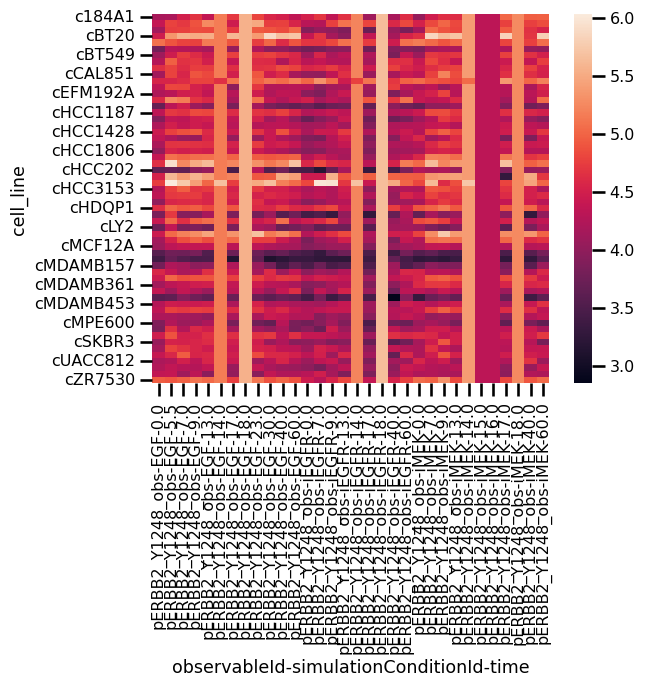

In [39]:
sns.heatmap(perbb2, xticklabels=True)

In [40]:
mat_nonans = mat.dropna(how="any", axis=1)

In [41]:
mat_nonans.shape

(58, 137)

In [42]:
res = (mat_nonans - mat_nonans.mean(axis=0)).apply(lambda x: np.power(x, 2)).mean(axis=1)
res.sort_values(ascending=False).head(10)
# top 5 cell-lines for deviation from the mean AFTER outlier: cHCC2185, cHCC1500, cUACC3199, cMCF7, CBT20

cell_line
cHCC1500       0.675744
cHCC2185       0.632264
cMCF7          0.541076
cUACC893       0.488004
cUACC3199      0.484012
cBT20          0.474431
cEVSAT         0.464575
cHCC1954       0.448395
cMDAMB134VI    0.376800
cHCC202        0.354854
dtype: float64

In [43]:
print(res.sort_values(ascending=False).head(10).index.values)

['cHCC1500' 'cHCC2185' 'cMCF7' 'cUACC893' 'cUACC3199' 'cBT20' 'cEVSAT'
 'cHCC1954' 'cMDAMB134VI' 'cHCC202']


<Axes: ylabel='Frequency'>

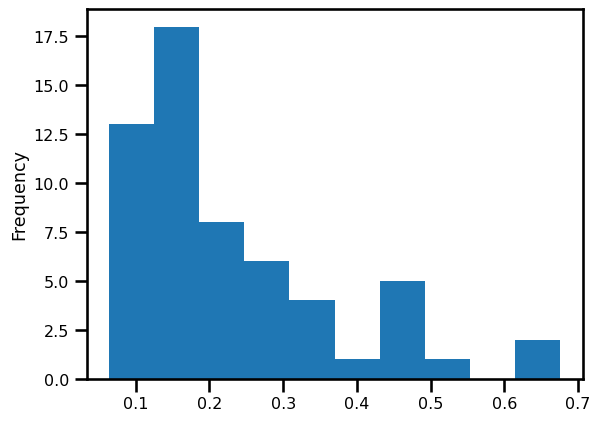

In [44]:
res.plot.hist()

In [45]:
mat.shape

(58, 137)

## After removing outlier HCC1599, mean changes so exact order of hardest cell-lines changes, but top 5 are the same cell-lines: HCC1500, HCC2185, MCF7, UACC3199 and BT20.

In [46]:
mat_nonans = mat.dropna(how="any", axis=1)
res = (mat_nonans - mat_nonans.mean(axis=0)).apply(lambda x: np.power(x, 2)).mean(axis=1)
res.sort_values(ascending=False).head(10)

cell_line
cHCC1500       0.675744
cHCC2185       0.632264
cMCF7          0.541076
cUACC893       0.488004
cUACC3199      0.484012
cBT20          0.474431
cEVSAT         0.464575
cHCC1954       0.448395
cMDAMB134VI    0.376800
cHCC202        0.354854
dtype: float64

# Inspect PCA

In [47]:
X = mat.values
# impute missing values prior to PCA
X_imputed = KNNImputer().fit_transform(X)

pca = PCA(n_components=10)
Xt = pca.fit_transform(X_imputed)

In [48]:
Xt.shape  # it appears 3 other cell-lines have been dropped (no transcriptomic data), previous notebook had 43 remaining cell-lines

(58, 10)

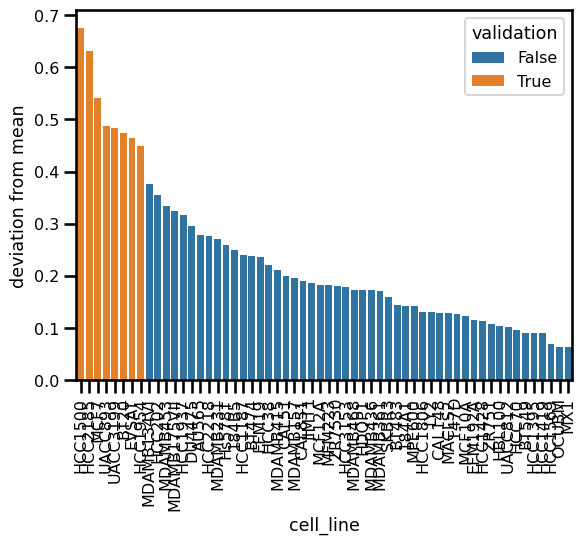

In [49]:
plt.rcParams.update({'font.size': 8})
res.name = "deviation from mean"
res.index.name = "cell_line"
res_df = res.reset_index()
res_df[res.index.name] = res_df[res.index.name].apply(lambda x: x[1:])
threshold = res.sort_values(ascending=False).head(8).min()
res_df["validation"] = res_df[res.name] >= threshold
res_df.sort_values(res.name, ascending=False, inplace=True)
sns.barplot(res_df, x=res.index.name, y=res.name, hue="validation", dodge=False)
# rotate x-axis labels
plt.xticks(rotation=90)
# decrease font size
res_df.set_index(res.index.name, inplace=True)

In [50]:
N_COMPS = 2
df = pd.DataFrame(
    index=[c[1:] for c in mat.index],
    data=Xt[:, :N_COMPS],
    columns=["PC1", "PC2"],
)
df.index.name = res.index.name
# select 5 strongest outliers as validation set
df["validation"] = res_df["validation"]
df

,PC1,PC2,validation
cell_line,,,
184A1,-2.307694,1.457923,False
184B5,-1.942913,3.931407,False
AU565,5.099186,0.101521,False
BT20,6.463580,2.763567,True
BT474,-3.740711,3.420915,False
BT483,-2.079905,-2.461758,False
BT549,-0.441406,0.135618,False
CAL148,-0.568881,1.088687,False
CAL51,4.046360,-0.672714,False


In [51]:
# Manually define annotation offsets to be able to read cell-line names
offsets = {
    # "HCC1599": {"ox": -1.7, "oy": -0.2},
    "MCF7": {"ox": -1.7, "oy": -0.2},
    "HCC1500": {"ox": 0.4, "oy": -0.2},
    "BT20": {"ox": 0.3, "oy": -0.2},
    "HCC2185": {"ox": 0.3, "oy": 0},
    "UACC3199": {"ox": -0.3, "oy": -0.5},
    "UACC893": {"ox": -0.3, "oy": -0.5},
    "HCC1954": {"ox": -0.3, "oy": -0.5},
    "EVSAT": {"ox": -0.3, "oy": -0.5},
}

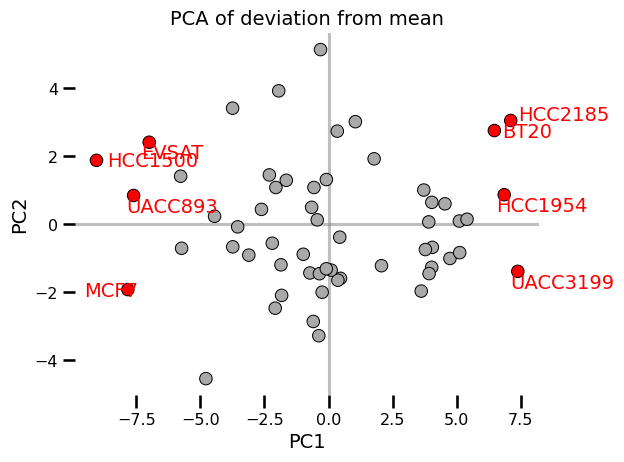

In [52]:
sns.set_context("talk", font_scale=0.7)
g = sns.scatterplot(
    data=df, 
    x="PC1", 
    y="PC2", 
    hue="validation",
    palette={True: "red", False: "darkgray"},
    edgecolor="black",
    legend=False
)
# add red colour for validation cell-lines
for _, r in df.iterrows():
    if r.validation or r.name in offsets.keys():
        plt.annotate(r.name, (r.PC1+offsets[r.name]["ox"], r.PC2+offsets[r.name]["oy"]), color="red", fontsize=14)

# export with transparent background and high dpi, remove grid
# no box around plot
# add dashed line at 0 for both axes with low order to ensure it is behind the data points
# make plot square
# make axis limits equal and remove axis labels
# g.set(xlim=(-7.2, 7.2), ylim=(-5, 5), aspect=1.0, xticks=[], yticks=[])
g.set_xlabel("PC1", fontsize=14)
g.set_ylabel("PC2", fontsize=14)
#
plt.axhline(0, color='gray', zorder=0, alpha=0.5)
plt.axvline(0, color='gray', zorder=0, alpha=0.5)
plt.box(False)
plt.grid(False)
VE = sum(pca.explained_variance_ratio_[:2])
# plt.title(f"PCA of deviance from mean ({VE*100:.0f}% Variance Explained)")
plt.title(f"PCA of deviation from mean", fontsize=14)
plt.tight_layout()
# plt.savefig("cytof_pca.png", transparent=True, dpi=300)


In [53]:
res_df = res.reset_index()
res_df["cell_line"] = res_df["cell_line"].apply(lambda x: x[1:])

scatter_df = df.reset_index().merge(res_df, on="cell_line", how="left")


In [54]:
pca.explained_variance_ratio_

array([0.49168113, 0.11085193, 0.08141995, 0.06787327, 0.05344369,
       0.03357435, 0.02329812, 0.01782783, 0.01354279, 0.01195545])

In [55]:
pca.components_.shape

(10, 137)

In [56]:
pc_mat = pd.DataFrame(
    index=[f"PC{i}" for i in np.arange(N_COMPS)],
    data=pca.components_[:N_COMPS, :],
    columns=mat.columns,
)
pc_mat

observableId          pERBB2_Y1248_obs                                \
simulationConditionId              EGF                                 
time                              0.0       5.5       7.0       9.0    
PC0                           0.029457  0.059016  0.055764  0.063617   
PC1                           0.131928  0.161069  0.161155  0.169075   

observableId                                                                 \
simulationConditionId                                                         
time                       13.0      14.0      17.0          18.0      23.0   
PC0                    0.060039 -0.000778  0.069976  5.562004e-18  0.044998   
PC1                    0.175659  0.005387  0.154074 -1.581741e-17  0.179077   

observableId                     ... pRPS6KA1_S380_obs                \
simulationConditionId            ...              iMEK                 
time                       30.0  ...              9.0           12.0   
PC0                    0.061356  ...          0.132539 -1.657417e-32   
PC1                    0.198965  ...          0.036202 -1.442933e-31   

observableId                                                            \
simulationConditionId                                                    
time                       13.0      14.0          15.0 16.0      17.0   
PC0                    0.132441  0.000143  1.657417e-32  0.0  0.127889   
PC1                   -0.045364 -0.000992  1.442933e-31 -0.0  0.020608   

observableId                                             
simulationConditionId                                    
time                           18.0      40.0      60.0  
PC0                    1.657417e-32  0.150075  0.122800  
PC1                    1.442933e-31  0.015350  0.054711  

[2 rows x 137 columns]

In [57]:
pc_mat.reset_index().columns

MultiIndex([(            'index',     '',   ''),
            ( 'pERBB2_Y1248_obs',  'EGF',  0.0),
            ( 'pERBB2_Y1248_obs',  'EGF',  5.5),
            ( 'pERBB2_Y1248_obs',  'EGF',  7.0),
            ( 'pERBB2_Y1248_obs',  'EGF',  9.0),
            ( 'pERBB2_Y1248_obs',  'EGF', 13.0),
            ( 'pERBB2_Y1248_obs',  'EGF', 14.0),
            ( 'pERBB2_Y1248_obs',  'EGF', 17.0),
            ( 'pERBB2_Y1248_obs',  'EGF', 18.0),
            ( 'pERBB2_Y1248_obs',  'EGF', 23.0),
            ...
            ('pRPS6KA1_S380_obs', 'iMEK',  9.0),
            ('pRPS6KA1_S380_obs', 'iMEK', 12.0),
            ('pRPS6KA1_S380_obs', 'iMEK', 13.0),
            ('pRPS6KA1_S380_obs', 'iMEK', 14.0),
            ('pRPS6KA1_S380_obs', 'iMEK', 15.0),
            ('pRPS6KA1_S380_obs', 'iMEK', 16.0),
            ('pRPS6KA1_S380_obs', 'iMEK', 17.0),
            ('pRPS6KA1_S380_obs', 'iMEK', 18.0),
            ('pRPS6KA1_S380_obs', 'iMEK', 40.0),
            ('pRPS6KA1_S380_obs', 'iMEK', 60.0)],
   

In [58]:
pc_mat_long = pd.melt(pc_mat.reset_index(), id_vars=[("index", "", "")])
pc_mat_long

,"(index, , )",observableId,simulationConditionId,time,value
0,PC0,pERBB2_Y1248_obs,EGF,0.0,2.945655e-02
1,PC1,pERBB2_Y1248_obs,EGF,0.0,1.319275e-01
2,PC0,pERBB2_Y1248_obs,EGF,5.5,5.901590e-02
3,PC1,pERBB2_Y1248_obs,EGF,5.5,1.610685e-01
4,PC0,pERBB2_Y1248_obs,EGF,7.0,5.576418e-02
...,...,...,...,...,...
269,PC1,pRPS6KA1_S380_obs,iMEK,18.0,1.442933e-31
270,PC0,pRPS6KA1_S380_obs,iMEK,40.0,1.500747e-01
271,PC1,pRPS6KA1_S380_obs,iMEK,40.0,1.535023e-02
272,PC0,pRPS6KA1_S380_obs,iMEK,60.0,1.227997e-01


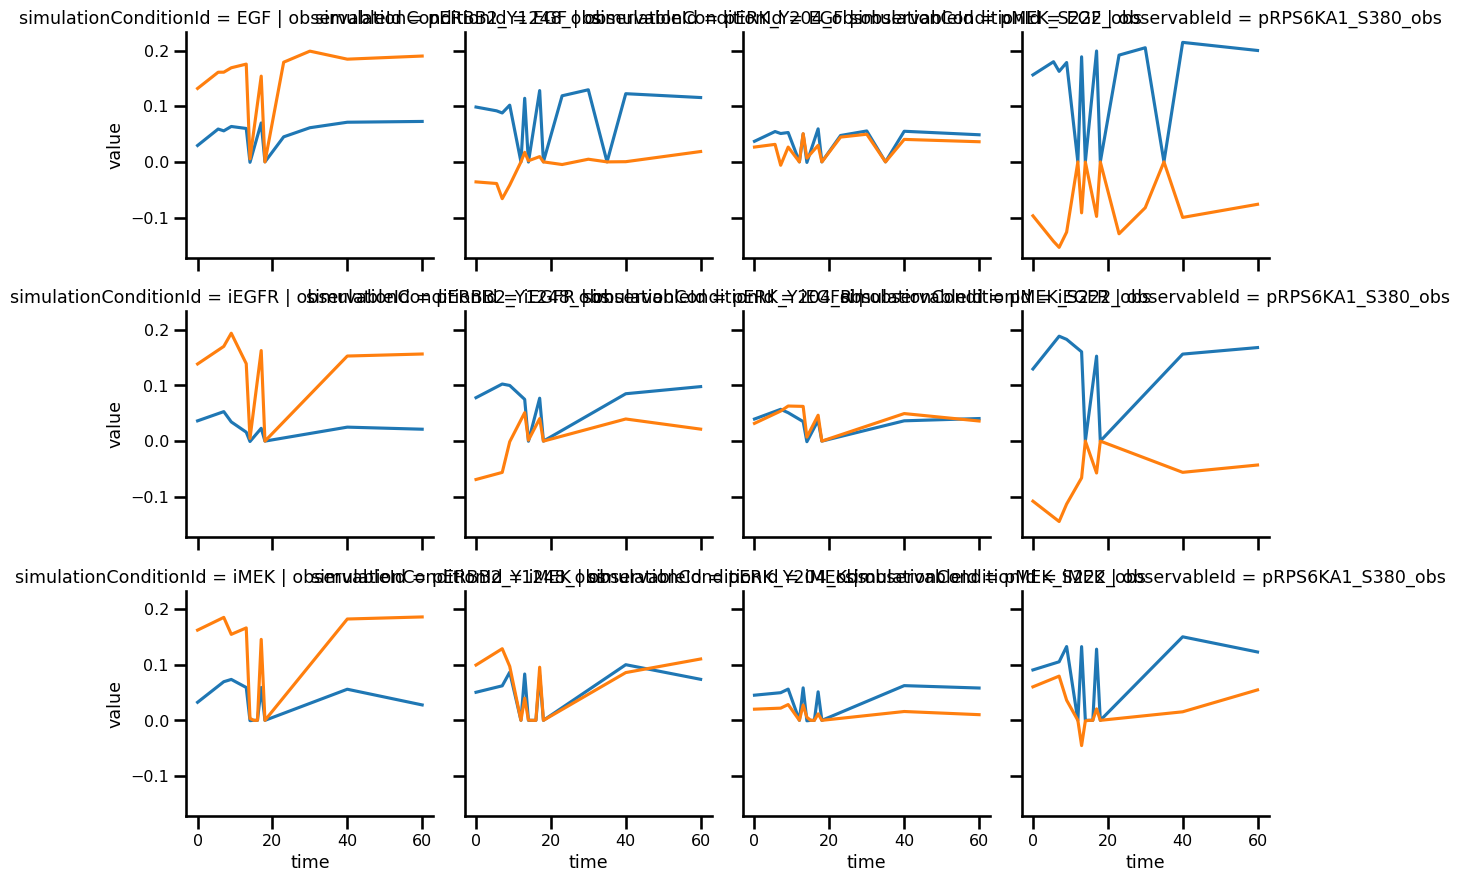

In [59]:
g = sns.FacetGrid(
    data=pc_mat_long, col=petab.OBSERVABLE_ID, row="simulationConditionId", hue=("index", "", "")
)
g.map_dataframe(sns.lineplot, x="time", y="value")
# Previous notebook showed 5 perturbation, but we have now removed iPI3K and iPKC -> 3 left (EGF, iEGFR, iMEK)